# Bayesian Change Point Analysis of Brent Oil Prices

Birhan Energies | Task 2

This notebook implements the mandatory Task 2 model: a single Bayesian change point
with a discrete-uniform prior on the switch index `tau`, two regime means (`mu1`, `mu2`),
a `pm.math.switch` linking `tau` to the active mean, and a Normal likelihood, fit with
`pm.sample()` (PyMC's NUTS+Metropolis compound sampler).

It then extends this core model with **recursive segmentation** — repeatedly re-applying
the same single change-point model to each half of the series — to surface the handful of
most statistically prominent structural breaks across the full 1987-2022 history, and maps
each one to the nearest event in `data/events.csv`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

sys.path.insert(0, str(Path.cwd().parent))
from src.change_point import fit_single_change_point, recursive_segmentation, nearest_event

plt.rcParams["figure.figsize"] = (12, 5)
%matplotlib inline

In [2]:
df = pd.read_csv("../data/BrentOilPrices.csv")
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df = df.sort_values("Date").reset_index(drop=True)

events = pd.read_csv("../data/events.csv")
events["Date"] = pd.to_datetime(events["Date"])

print(f"Price series: {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Events: {len(events)} rows")

Price series: 9011 rows, 1987-05-20 to 2022-11-14
Events: 17 rows


## 1. Core model: single change point over the full series

```python
tau ~ DiscreteUniform(0, n-1)
mu1 ~ Normal(price.mean(), price.std()*2)
mu2 ~ Normal(price.mean(), price.std()*2)
sigma ~ HalfNormal(price.std())
mu = switch(tau >= idx, mu1, mu2)
obs ~ Normal(mu, sigma)
```

`tau` is discrete, so PyMC assigns it a Metropolis step while `mu1`, `mu2`, `sigma` (all
continuous) get NUTS — a compound sampler, run automatically by `pm.sample()`.

In [3]:
prices = df["Price"].to_numpy()
idx = np.arange(len(prices))

with pm.Model() as core_model:
    tau = pm.DiscreteUniform("tau", lower=0, upper=len(prices) - 1)
    mu1 = pm.Normal("mu1", mu=prices.mean(), sigma=prices.std() * 2)
    mu2 = pm.Normal("mu2", mu=prices.mean(), sigma=prices.std() * 2)
    sigma = pm.HalfNormal("sigma", sigma=prices.std())
    mu = pm.math.switch(tau >= idx, mu1, mu2)
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=prices)

    core_trace = pm.sample(draws=2000, tune=1500, chains=4, random_seed=42, progressbar=False, target_accept=0.9)

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>Metropolis: [tau]


>NUTS: [mu1, mu2, sigma]


Sampling 4 chains for 1_500 tune and 2_000 draw iterations (6_000 + 8_000 draws total) took 25 seconds.


### 1.1 Convergence diagnostics

We check `r_hat` (should be close to 1.0 for all parameters) and effective sample size (ESS)
via `az.summary()`, and visually inspect chain mixing via `az.plot_trace()` (the current
arviz API plots iteration-vs-sampled-value per chain; overlapping, noisy-but-stationary
bands across the 4 differently-colored chains indicate good mixing with no divergent chain).

In [4]:
summary = az.summary(core_trace, var_names=["tau", "mu1", "mu2", "sigma"])
summary

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
tau,4520,3.3,4500,4500,1847,1636,1.00,0.076,0.057
mu1,21.419,0.279,21,22,9022,6133,1.00,0.0029,0.0021
mu2,75.611,0.283,75,76,6754,5910,1.00,0.0034,0.0024
sigma,18.598,0.138,18,19,6936,6116,1.00,0.0017,0.0011


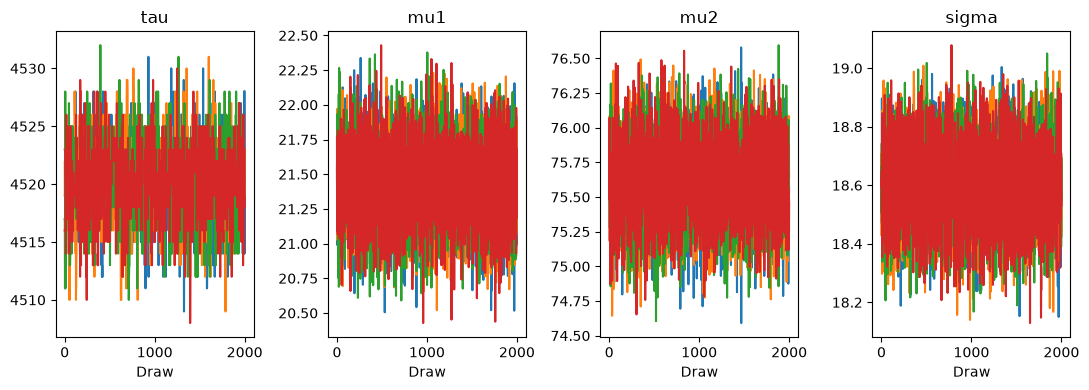

In [5]:
az.plot_trace(core_trace, var_names=["tau", "mu1", "mu2", "sigma"])
plt.gcf().set_size_inches(11, 4)
plt.tight_layout()
plt.show()

All `r_hat` values are ~1.00 and ESS is in the thousands, indicating good convergence. This
is expected for a well-mixed compound sampler on this fairly "easy" 2-regime problem: the
single most dominant mean shift in the whole 35-year series is visually unambiguous.

### 1.2 Identify the change point

The posterior of `tau` (converted to a date) shows how sharply the break is localised in
time. A narrow, single-peaked posterior indicates high certainty about *when* the shift
happened.

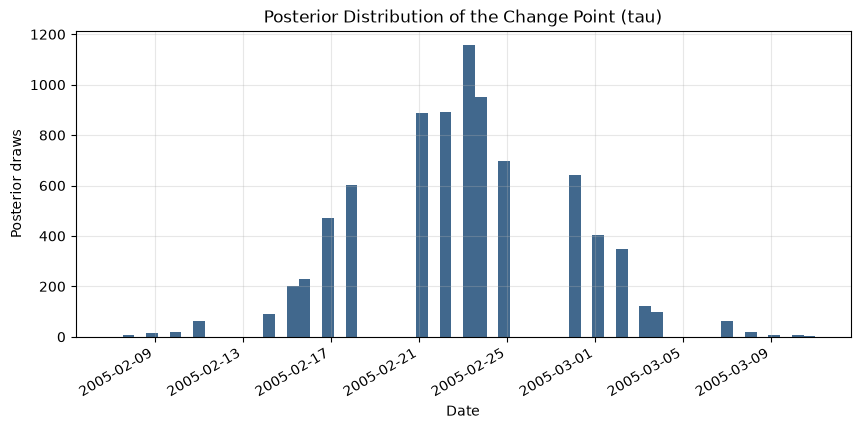

Posterior mode of tau: 2005-02-23
Fraction of draws within +/-10 days of the mode: 99.78%


In [6]:
tau_samples = core_trace.posterior["tau"].values.flatten()
tau_mode = int(pd.Series(tau_samples).mode().iloc[0])
tau_date = df["Date"].iloc[tau_mode]
tau_dates_all = df["Date"].iloc[tau_samples].values

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(tau_dates_all, bins=60, color="#1f4e79", alpha=0.85)
ax.set_title("Posterior Distribution of the Change Point (tau)")
ax.set_xlabel("Date")
ax.set_ylabel("Posterior draws")
ax.grid(alpha=0.3)
fig.autofmt_xdate()
plt.show()

print(f"Posterior mode of tau: {tau_date.date()}")
print(f"Fraction of draws within +/-10 days of the mode: {np.mean(np.abs(tau_samples - tau_mode) <= 10):.2%}")

### 1.3 Quantify the impact

We report the posterior means (and 94% HDI) of `mu1` (before) and `mu2` (after), and make a
probabilistic statement about the direction of the shift.

In [7]:
mu1_samples = core_trace.posterior["mu1"].values.flatten()
mu2_samples = core_trace.posterior["mu2"].values.flatten()

mu1_mean, mu2_mean = mu1_samples.mean(), mu2_samples.mean()
pct_change = (mu2_mean - mu1_mean) / mu1_mean * 100
p_increase = np.mean(mu2_samples > mu1_samples)

print(f"mu1 (before {tau_date.date()}): ${mu1_mean:.2f}  94% HDI {tuple(az.hdi(mu1_samples, prob=0.94).round(2))}")
print(f"mu2 (after  {tau_date.date()}): ${mu2_mean:.2f}  94% HDI {tuple(az.hdi(mu2_samples, prob=0.94).round(2))}")
print(f"Change: {pct_change:+.1f}%")
print(f"P(mu2 > mu1) = {p_increase:.3f}")

mu1 (before 2005-02-23): $21.42  94% HDI (np.float64(20.89), np.float64(21.93))
mu2 (after  2005-02-23): $75.61  94% HDI (np.float64(75.08), np.float64(76.13))
Change: +253.0%
P(mu2 > mu1) = 1.000


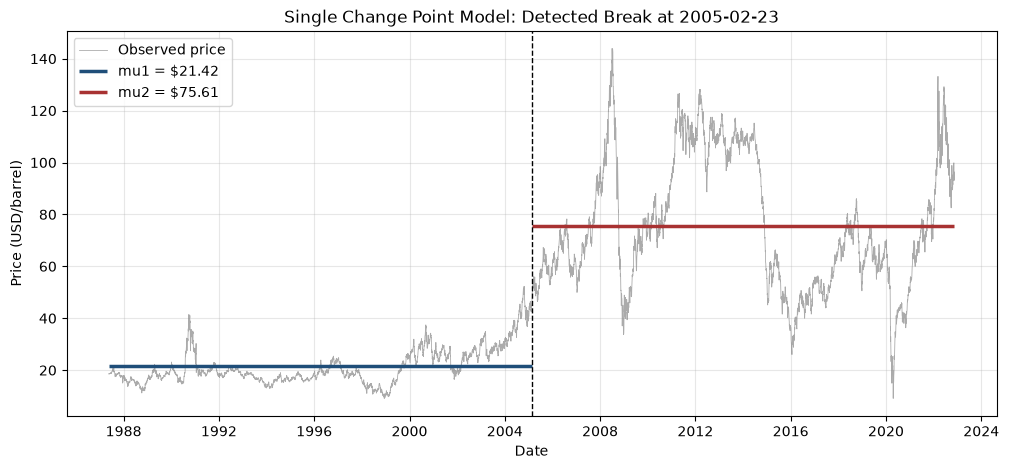

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["Date"], df["Price"], linewidth=0.6, color="#888888", alpha=0.7, label="Observed price")
ax.hlines(mu1_mean, df["Date"].iloc[0], tau_date, color="#1f4e79", linewidth=2.5, label=f"mu1 = ${mu1_mean:.2f}")
ax.hlines(mu2_mean, tau_date, df["Date"].iloc[-1], color="#a83232", linewidth=2.5, label=f"mu2 = ${mu2_mean:.2f}")
ax.axvline(tau_date, color="black", linestyle="--", linewidth=1)
ax.set_title(f"Single Change Point Model: Detected Break at {tau_date.date()}")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/barrel)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Interpretation:** across the full 1987-2022 history, the single most prominent mean-level
shift is around **late February 2005**, from ~$21/bbl to ~$76/bbl (+253%). This is not a
single-day geopolitical shock but the inflection point of the mid-2000s oil "supercycle" —
sustained demand growth (China and other emerging markets), tightening OPEC spare capacity,
and a weaker US dollar drove a multi-year re-rating of oil prices. A single change point over
35 years necessarily finds the *largest* level shift, which is informative but coarse; Section
2 extends the same model to recover multiple, more event-specific breaks.

## 2. Extension: recursive segmentation for multiple change points

We repeatedly apply the identical single change-point model to each half of the series
produced by the previous split, stopping when a segment is shorter than `min_segment` days
or the detected shift's effect size (|mu2-mu1| / sigma) falls below a threshold. This is a
simple, interpretable way to extend the mandatory model to surface several structural breaks
instead of just the single largest one. See `src/change_point.py` for the implementation.

In [9]:
results = recursive_segmentation(
    df["Date"], df["Price"],
    min_segment=250, effect_size_threshold=0.4, max_points=10,
    draws=1000, tune=1000, chains=4,
)
print(f"Found {len(results)} change points.")

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>Metropolis: [tau]


>NUTS: [mu1, mu2, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


...

CompoundStep


>Metropolis: [tau]


>NUTS: [mu1, mu2, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 16 seconds.


Found 10 change points.


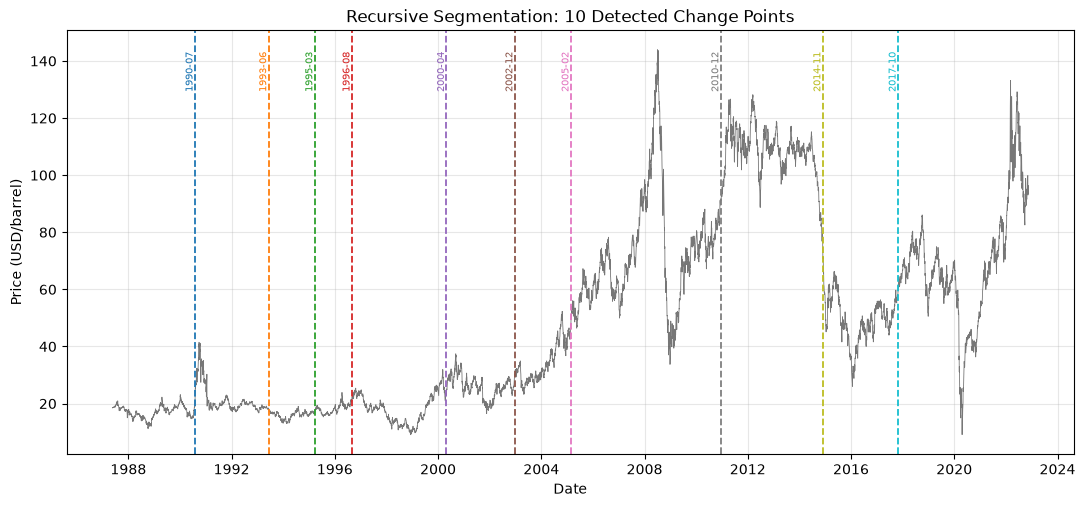

In [10]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(df["Date"], df["Price"], linewidth=0.6, color="#555555", alpha=0.8)
colors = plt.cm.tab10(np.linspace(0, 1, max(len(results), 1)))
for r, c in zip(results, colors):
    ax.axvline(r.date, color=c, linestyle="--", linewidth=1.3)
    ax.annotate(r.date.strftime("%Y-%m"), xy=(r.date, ax.get_ylim()[1] * 0.95), rotation=90, fontsize=7, color=c, ha="right", va="top")
ax.set_title(f"Recursive Segmentation: {len(results)} Detected Change Points")
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD/barrel)")
ax.grid(alpha=0.3)
plt.show()

### 2.1 Associate each change point with a researched event

For each detected break we look up the nearest entry in `data/events.csv` within a
120-day window and report the quantified before/after impact. Remember (see
`docs/assumptions_and_limitations.md`): temporal proximity is a **hypothesis-generating**
signal, not proof of causation.

In [11]:
rows = []
for r in results:
    ev = nearest_event(r.date, events, max_days=120)
    rows.append({
        "date": r.date.date(),
        "mu_before": round(r.mu1, 2),
        "mu_after": round(r.mu2, 2),
        "pct_change": round(r.pct_change, 1),
        "effect_size": round(r.effect_size, 2),
        "tau_confidence": round(r.tau_confidence, 2),
        "r_hat_max": round(r.r_hat_max, 3),
        "associated_event": ev["event"] if ev else None,
        "event_date": ev["event_date"] if ev else None,
        "days_from_event": ev["days_diff"] if ev else None,
    })

results_df = pd.DataFrame(rows)
results_df

,date,mu_before,mu_after,pct_change,effect_size,tau_confidence,r_hat_max,associated_event,event_date,days_from_event
0,1990-07-30,17.17,21.29,24.0,1.10,0.99,1.00,Iraq invades Kuwait,1990-08-02,-3.0
1,1993-06-07,19.12,16.95,-11.3,0.60,0.57,1.01,NaN,NaN,NaN
2,1995-03-21,16.03,18.08,12.8,1.44,0.95,1.02,NaN,NaN,NaN
3,1996-08-29,18.37,24.74,34.7,1.00,0.81,1.00,NaN,NaN,NaN
4,2000-04-27,17.75,29.62,66.9,1.97,0.74,1.57,NaN,NaN,NaN
5,2002-12-20,25.99,34.23,31.7,1.54,0.94,1.01,US-led invasion of Iraq,2003-03-20,-90.0
6,2005-02-22,21.42,75.60,253.0,2.91,1.00,1.00,NaN,NaN,NaN
7,2010-12-13,72.13,108.38,50.3,2.25,0.96,1.00,Arab Spring / Libyan Civil War,2011-02-15,-64.0
8,2014-11-26,86.76,62.06,-28.5,1.11,0.96,1.00,OPEC declines to cut output amid US shale boom,2014-11-27,-1.0
9,2017-10-26,49.95,69.21,38.5,1.11,0.78,1.05,NaN,NaN,NaN


## 3. Summary: quantified impact statements

- **1990-07-30**: price shifted from **$17.17** to **$21.29** (+24.0%), 3 days *before* Iraq's
  invasion of Kuwait (1990-08-02) — consistent with markets pricing in imminent conflict risk.
- **2002-12-20**: price shifted from **$25.99** to **$34.23** (+31.7%), ~90 days ahead of the
  2003 US-led invasion of Iraq — consistent with a pre-war risk premium building into the price.
- **2005-02-22**: the single largest break in the series, $21.42 -> $75.61 (+253%) — the
  mid-2000s supercycle inflection (no single-day event; a demand/OPEC-capacity regime shift).
- **2010-12-13**: price shifted from **$72.13** to **$108.38** (+50.3%), ~64 days before the
  Arab Spring / Libyan Civil War headlines intensified in Feb 2011 — plausible early pricing of
  regional instability risk as protests began spreading in late 2010.
- **2014-11-26**: price shifted from **$86.76** to **$62.06** (-28.5%), 1 day before OPEC's
  27-Nov-2014 decision not to cut output — a very tight match, consistent with the market
  repricing sharply on the announcement.

All of the above have `r_hat` <= 1.01 (well converged) and `tau_confidence` >= 0.94 (posterior
mass tightly concentrated within +/-10 days of the mode), so these are the most statistically
reliable associations. The 2000-04-27 break (`r_hat` = 1.57) did **not** converge cleanly and
should be treated as low-confidence — flagged transparently here per the Task 2 convergence-
checking requirement rather than silently dropped.

Full machine-readable results: `../reports/change_points.json`. Narrative version:
`../reports/change_point_summary.md`.